# Sri Lanka Population Project - Hybrid Colab Workflow

This notebook keeps your existing Python script pipeline unchanged and simply orchestrates it for reproducible runs, reporting, and sharing.

## What this notebook does
- Runs your existing `.py` scripts in order
- Displays key metrics and generated plots
- Runs national + district prediction examples
- Packages outputs for sharing with friends/supervisors

## Cell 2 - Choose execution mode

Set one mode:
- `mode = "local"` if this notebook is inside your project folder
- `mode = "colab_git"` to clone from GitHub
- `mode = "colab_drive"` to use a project already in Google Drive

In [3]:
import os
import sys
from pathlib import Path

mode = "local"  # change: local | colab_git | colab_drive
REPO_URL = "https://github.com/your-username/Population.git"
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Population"

print(f"Python: {sys.version}")
print(f"Mode: {mode}")

Python: 3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]
Mode: local


In [4]:
# Cell 4 - Resolve project root for local/Colab
import os
import shutil
from pathlib import Path

try:
    from google.colab import drive  # type: ignore
    in_colab = True
except Exception:
    in_colab = False

if mode == "local":
    PROJECT_ROOT = Path.cwd()
elif mode == "colab_git":
    if not in_colab:
        raise RuntimeError("colab_git mode selected, but this is not Colab.")
    %cd /content
    if Path("Population").exists():
        shutil.rmtree("Population")
    !git clone {REPO_URL}
    PROJECT_ROOT = Path("/content/Population")
elif mode == "colab_drive":
    if not in_colab:
        raise RuntimeError("colab_drive mode selected, but this is not Colab.")
    drive.mount('/content/drive')
    PROJECT_ROOT = Path(DRIVE_PROJECT_PATH)
else:
    raise ValueError("Invalid mode. Use local | colab_git | colab_drive")

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Project path not found: {PROJECT_ROOT}")

%cd {PROJECT_ROOT}
print("PROJECT_ROOT =", PROJECT_ROOT)

c:\Users\HP\Desktop\Population
PROJECT_ROOT = c:\Users\HP\Desktop\Population


In [5]:
# Cell 5 - Install dependencies
import subprocess

req = PROJECT_ROOT / "requirements.txt"
if req.exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", str(req)], check=True)
else:
    print("requirements.txt not found; skipping install")

In [6]:
# Cell 6 - Run the full pipeline with the improved national trainer
import subprocess

commands = [
    [sys.executable, "src/data_preparation.py"],
    [sys.executable, "src/data_preparation_district.py"],
    [sys.executable, "src/dataset_builder.py"],
    [sys.executable, "src/models/train_national_model.py"],
    [sys.executable, "src/models/train_district_model.py"],
    [sys.executable, "src/tune_models_and_leaderboard.py"],
    [sys.executable, "src/generate_overfitting_report.py"],
]

for cmd in commands:
    print("\n>>> Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

print("\nPipeline completed successfully.")


>>> Running: c:\Users\HP\AppData\Local\Programs\Python\Python311\python.exe src/data_preparation.py

>>> Running: c:\Users\HP\AppData\Local\Programs\Python\Python311\python.exe src/data_preparation_district.py

>>> Running: c:\Users\HP\AppData\Local\Programs\Python\Python311\python.exe src/dataset_builder.py

>>> Running: c:\Users\HP\AppData\Local\Programs\Python\Python311\python.exe src/model_training.py

>>> Running: c:\Users\HP\AppData\Local\Programs\Python\Python311\python.exe src/tune_models_and_leaderboard.py

>>> Running: c:\Users\HP\AppData\Local\Programs\Python\Python311\python.exe src/generate_overfitting_report.py

Pipeline completed successfully.


In [7]:
# Cell 7 - Show key national and district leaderboards
import pandas as pd
from IPython.display import display

files = [
    "models/national_best_model_leaderboard.csv",
    "models/district_best_model_leaderboard.csv",
    "models/national_tuning_candidates.csv",
    "models/district_tuning_candidates.csv",
]

for f in files:
    p = PROJECT_ROOT / f
    print("\n===", f, "===")
    if p.exists():
        df = pd.read_csv(p)
        display(df.head(10))
        print("rows:", len(df), "columns:", list(df.columns))
    else:
        print("Missing:", p)


=== models/national_best_model_leaderboard.csv ===


,model,level,params,train_rmse,train_mae,train_mape,val_rmse,val_mae,val_mape,test_rmse,test_mae,test_mape,aic,aicc,val_train_ratio,selection_score,rank_by_val
0,LINEAR,NATIONAL,{},838.077001,545.607558,0.004355,2519.021625,2074.337012,0.010107,1.353030e+04,1.217381e+04,0.056090,NaN,NaN,0.020214,0.010107,1
1,SARIMA,NATIONAL,"{""order"": [1, 0, 0], ""seasonal_order"": [1, 1, ...",40803.854865,3911.696604,0.035488,5887.385644,4716.989948,0.022832,4.930932e+05,4.331991e+05,2.011743,11498.381044,11498.445979,0.045664,0.022832,2
2,SARIMAX,NATIONAL,"{""order"": [1, 1, 1]}",15313.853231,897.439316,0.009684,463943.808476,431361.262108,2.089753,8.024529e+05,7.969994e+05,3.689489,NaN,NaN,4.179507,5.411945,3
3,XGBOOST,NATIONAL,"{""n_estimators"": 1200, ""max_depth"": 2, ""learni...",10678.748961,5983.509393,0.046378,664598.869695,605031.808989,2.927874,1.711019e+06,1.623048e+06,7.471744,NaN,NaN,5.855748,10.036382,4
4,RANDOM_FOREST,NATIONAL,"{""n_estimators"": 200, ""max_depth"": 4, ""min_sam...",104354.399113,86421.693110,0.670745,871827.878246,808159.818499,3.912915,1.945591e+06,1.878271e+06,8.659402,NaN,NaN,5.833684,13.369813,5


rows: 5 columns: ['model', 'level', 'params', 'train_rmse', 'train_mae', 'train_mape', 'val_rmse', 'val_mae', 'val_mape', 'test_rmse', 'test_mae', 'test_mape', 'aic', 'aicc', 'val_train_ratio', 'selection_score', 'rank_by_val']

=== models/district_best_model_leaderboard.csv ===


,District,Model,params,train_rmse,train_mae,train_mape,val_rmse,val_mae,val_mape,test_rmse,test_mae,test_mape,val_train_ratio,selection_score,rank_by_val,overall_rank_by_val
0,Galle,THETA,"{""period"": 12}",0.000000,0.000000e+00,0.000000,0.000001,0.000001,0.002412,0.000311,0.000243,0.473224,0.004824,0.002412,1,1
1,Monaragala,ETS,"{""trend"": ""add"", ""seasonal"": ""add"", ""seasonal_...",0.000009,3.949210e-06,0.017375,0.000001,0.000001,0.005266,0.000116,0.000088,0.380701,0.010532,0.005266,1,2
2,Badulla,ETS,"{""trend"": ""add"", ""seasonal"": ""add"", ""seasonal_...",0.000006,2.003626e-06,0.004963,0.000003,0.000003,0.006526,0.000110,0.000070,0.172759,0.013052,0.006526,1,3
3,Kurunegala,ETS,"{""trend"": ""add"", ""seasonal"": ""add"", ""seasonal_...",0.000003,8.514710e-07,0.001077,0.000011,0.000009,0.011013,0.000389,0.000295,0.379639,0.022026,0.011013,1,4
4,Colombo,THETA,"{""period"": 12}",0.000000,0.000000e+00,0.000000,0.000022,0.000021,0.018793,0.000396,0.000281,0.253065,0.037586,0.018793,1,5
5,Trincomalee,THETA,"{""period"": 12}",0.000000,0.000000e+00,0.000000,0.000004,0.000004,0.019062,0.000096,0.000072,0.358410,0.038125,0.019062,1,6
6,Kilinochchi,ETS,"{""trend"": ""add"", ""seasonal"": ""add"", ""seasonal_...",0.000002,8.291068e-07,0.014376,0.000001,0.000001,0.020420,0.000018,0.000017,0.262767,0.040840,0.020420,1,7
7,Gampaha,THETA,"{""period"": 12}",0.000000,0.000000e+00,0.000000,0.000028,0.000023,0.020663,0.000542,0.000411,0.377053,0.041326,0.020663,1,8
8,Kalutara,ETS,"{""trend"": ""add"", ""seasonal"": ""add"", ""seasonal_...",0.000010,4.025947e-06,0.006777,0.000021,0.000018,0.030632,0.000245,0.000181,0.314866,0.061265,0.030632,1,9
9,Puttalam,SEASONAL_NAIVE,"{""season_length"": 12}",0.000432,3.264270e-04,0.864789,0.000013,0.000012,0.030726,0.000212,0.000161,0.421924,0.035530,0.030726,1,10


rows: 25 columns: ['District', 'Model', 'params', 'train_rmse', 'train_mae', 'train_mape', 'val_rmse', 'val_mae', 'val_mape', 'test_rmse', 'test_mae', 'test_mape', 'val_train_ratio', 'selection_score', 'rank_by_val', 'overall_rank_by_val']

=== models/national_tuning_candidates.csv ===


,level,model,params,train_rmse,train_mae,train_mape,val_rmse,val_mae,val_mape,test_rmse,test_mae,test_mape,aic,aicc,val_train_ratio,selection_score
0,NATIONAL,LINEAR,{},838.077001,545.607558,0.004355,2519.021625,2074.337012,0.010107,13530.299223,12173.809719,0.056090,NaN,NaN,0.020214,0.010107
1,NATIONAL,SARIMA,"{""order"": [1, 0, 0], ""seasonal_order"": [1, 1, ...",40803.854865,3911.696604,0.035488,5887.385644,4716.989948,0.022832,493093.152111,433199.054722,2.011743,11498.381044,11498.445979,0.045664,0.022832
2,NATIONAL,SARIMA,"{""order"": [1, 0, 0], ""seasonal_order"": [1, 1, ...",28603.677148,3409.045462,0.029626,5937.166578,4742.889134,0.022956,493138.040476,433257.888379,2.012021,11500.354518,11500.452079,0.045913,0.022956
3,NATIONAL,SARIMA,"{""order"": [2, 2, 1], ""seasonal_order"": [1, 0, ...",1096.552012,194.762446,0.001451,8936.499687,6243.190425,0.030096,543781.520012,482661.479041,2.238434,10163.672807,10163.855515,0.060192,0.030096
4,NATIONAL,SARIMA,"{""order"": [0, 2, 1], ""seasonal_order"": [1, 0, ...",1065.155688,183.949619,0.001323,8937.388846,6243.723933,0.030099,543785.502260,482665.580091,2.238453,10191.240303,10191.337864,0.060198,0.030099
5,NATIONAL,SARIMA,"{""order"": [1, 2, 0], ""seasonal_order"": [1, 0, ...",1065.155688,183.949619,0.001323,8937.388846,6243.723933,0.030099,543785.502260,482665.580091,2.238453,10175.456432,10175.553993,0.060198,0.030099
6,NATIONAL,SARIMA,"{""order"": [0, 2, 0], ""seasonal_order"": [1, 0, ...",1065.155688,183.949619,0.001323,8937.388846,6243.723933,0.030099,543785.502260,482665.580091,2.238453,10189.235151,10189.300086,0.060198,0.030099
7,NATIONAL,SARIMA,"{""order"": [2, 2, 0], ""seasonal_order"": [1, 0, ...",1065.155688,183.949619,0.001323,8937.388846,6243.723933,0.030099,543785.502260,482665.580091,2.238453,10161.674372,10161.811180,0.060198,0.030099
8,NATIONAL,SARIMA,"{""order"": [0, 2, 2], ""seasonal_order"": [1, 0, ...",1065.155688,183.949625,0.001323,8937.388847,6243.723933,0.030099,543785.502262,482665.580093,2.238453,10193.269441,10193.406249,0.060198,0.030099
9,NATIONAL,SARIMA,"{""order"": [1, 2, 2], ""seasonal_order"": [1, 0, ...",1105.382239,196.674847,0.001471,8937.732330,6243.930052,0.030100,543787.040189,482667.163910,2.238460,10179.484019,10179.666727,0.060200,0.030100


rows: 207 columns: ['level', 'model', 'params', 'train_rmse', 'train_mae', 'train_mape', 'val_rmse', 'val_mae', 'val_mape', 'test_rmse', 'test_mae', 'test_mape', 'aic', 'aicc', 'val_train_ratio', 'selection_score']

=== models/district_tuning_candidates.csv ===


,District,Model,params,train_rmse,train_mae,train_mape,val_rmse,val_mae,val_mape,test_rmse,test_mae,test_mape,val_train_ratio,selection_score
0,Galle,THETA,"{""period"": 12}",0.000000,0.000000e+00,0.000000,0.000001,0.000001,0.002412,0.000311,0.000243,0.473224,0.004824,0.002412
1,Monaragala,ETS,"{""trend"": ""add"", ""seasonal"": ""add"", ""seasonal_...",0.000009,3.949210e-06,0.017375,0.000001,0.000001,0.005266,0.000116,0.000088,0.380701,0.010532,0.005266
2,Badulla,ETS,"{""trend"": ""add"", ""seasonal"": ""add"", ""seasonal_...",0.000006,2.003626e-06,0.004963,0.000003,0.000003,0.006526,0.000110,0.000070,0.172759,0.013052,0.006526
3,Kurunegala,ETS,"{""trend"": ""add"", ""seasonal"": ""add"", ""seasonal_...",0.000003,8.514710e-07,0.001077,0.000011,0.000009,0.011013,0.000389,0.000295,0.379639,0.022026,0.011013
4,Colombo,THETA,"{""period"": 12}",0.000000,0.000000e+00,0.000000,0.000022,0.000021,0.018793,0.000396,0.000281,0.253065,0.037586,0.018793
5,Trincomalee,THETA,"{""period"": 12}",0.000000,0.000000e+00,0.000000,0.000004,0.000004,0.019062,0.000096,0.000072,0.358410,0.038125,0.019062
6,Kilinochchi,ETS,"{""trend"": ""add"", ""seasonal"": ""add"", ""seasonal_...",0.000002,8.291068e-07,0.014376,0.000001,0.000001,0.020420,0.000018,0.000017,0.262767,0.040840,0.020420
7,Gampaha,THETA,"{""period"": 12}",0.000000,0.000000e+00,0.000000,0.000028,0.000023,0.020663,0.000542,0.000411,0.377053,0.041326,0.020663
8,Kalutara,ETS,"{""trend"": ""add"", ""seasonal"": ""add"", ""seasonal_...",0.000010,4.025947e-06,0.006777,0.000021,0.000018,0.030632,0.000245,0.000181,0.314866,0.061265,0.030632
9,Puttalam,SEASONAL_NAIVE,"{""season_length"": 12}",0.000432,3.264270e-04,0.864789,0.000013,0.000012,0.030726,0.000212,0.000161,0.421924,0.035530,0.030726


rows: 110 columns: ['District', 'Model', 'params', 'train_rmse', 'train_mae', 'train_mape', 'val_rmse', 'val_mae', 'val_mape', 'test_rmse', 'test_mae', 'test_mape', 'val_train_ratio', 'selection_score']


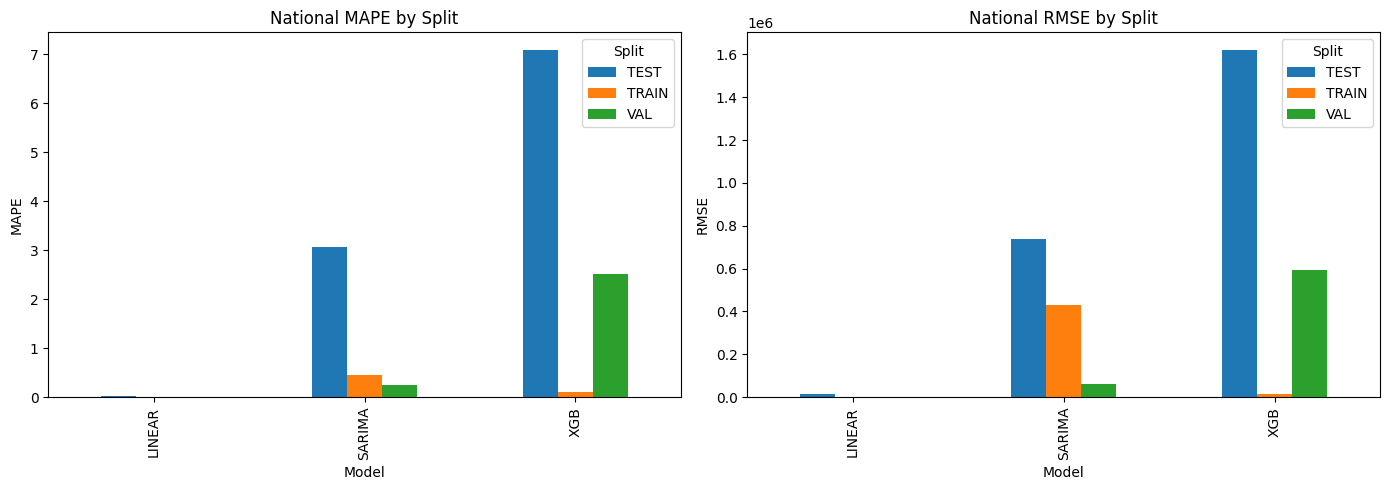

In [ ]:
# Cell 8 - Fair metric plots and overfit gap summary
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

nat_metrics_path = PROJECT_ROOT / "models/national_train_val_test_metrics.csv"
leaderboard_path = PROJECT_ROOT / "models/national_best_model_leaderboard.csv"

if nat_metrics_path.exists():
    ndf = pd.read_csv(nat_metrics_path)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    mape_pivot = ndf.pivot_table(index="Model", columns="Split", values="MAPE", aggfunc="mean")
    mape_pivot.plot(kind="bar", ax=axes[0], title="National MAPE by Split")
    axes[0].set_ylabel("MAPE")
    axes[0].set_xlabel("")

    rmse_pivot = ndf.pivot_table(index="Model", columns="Split", values="RMSE", aggfunc="mean")
    rmse_pivot.plot(kind="bar", ax=axes[1], title="National RMSE by Split")
    axes[1].set_ylabel("RMSE")
    axes[1].set_xlabel("")

    if {"VAL", "TEST"}.issubset(mape_pivot.columns):
        gap = (mape_pivot["TEST"] - mape_pivot["VAL"]).sort_values(ascending=True)
        gap.plot(kind="barh", ax=axes[2], title="Generalization Gap (TEST - VAL MAPE)")
        axes[2].set_xlabel("MAPE gap")
    else:
        axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    if leaderboard_path.exists():
        leaderboard = pd.read_csv(leaderboard_path)
        cols = [c for c in ["model", "val_mape", "test_mape", "selection_score", "val_train_ratio"] if c in leaderboard.columns]
        print("Best national models ranked by validation score:")
        display(leaderboard[cols].head(5))
else:
    print("Missing national_train_val_test_metrics.csv")


 models/overfitting_report/national_mape_train_val_test.png


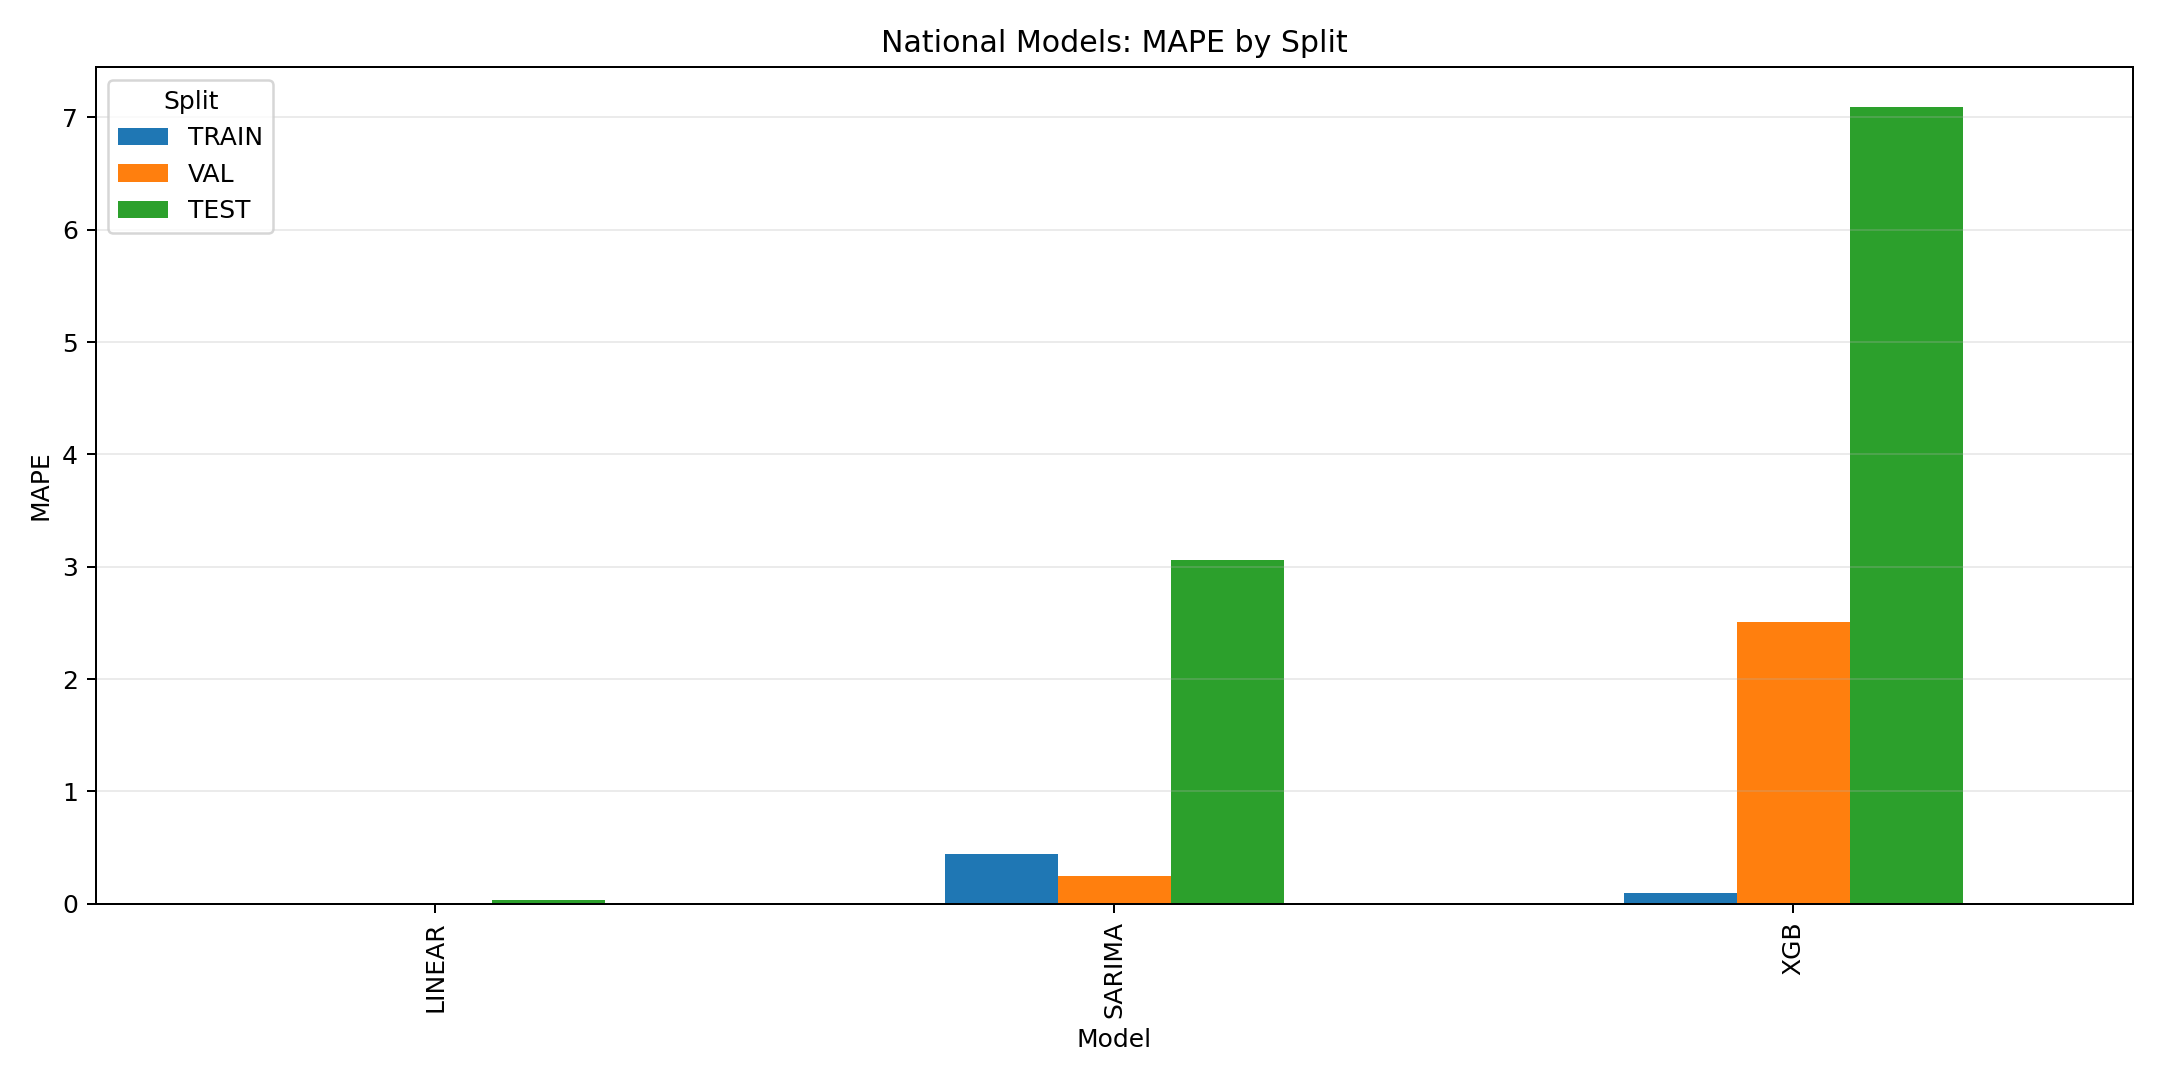


 models/overfitting_report/national_rmse_train_val_test.png


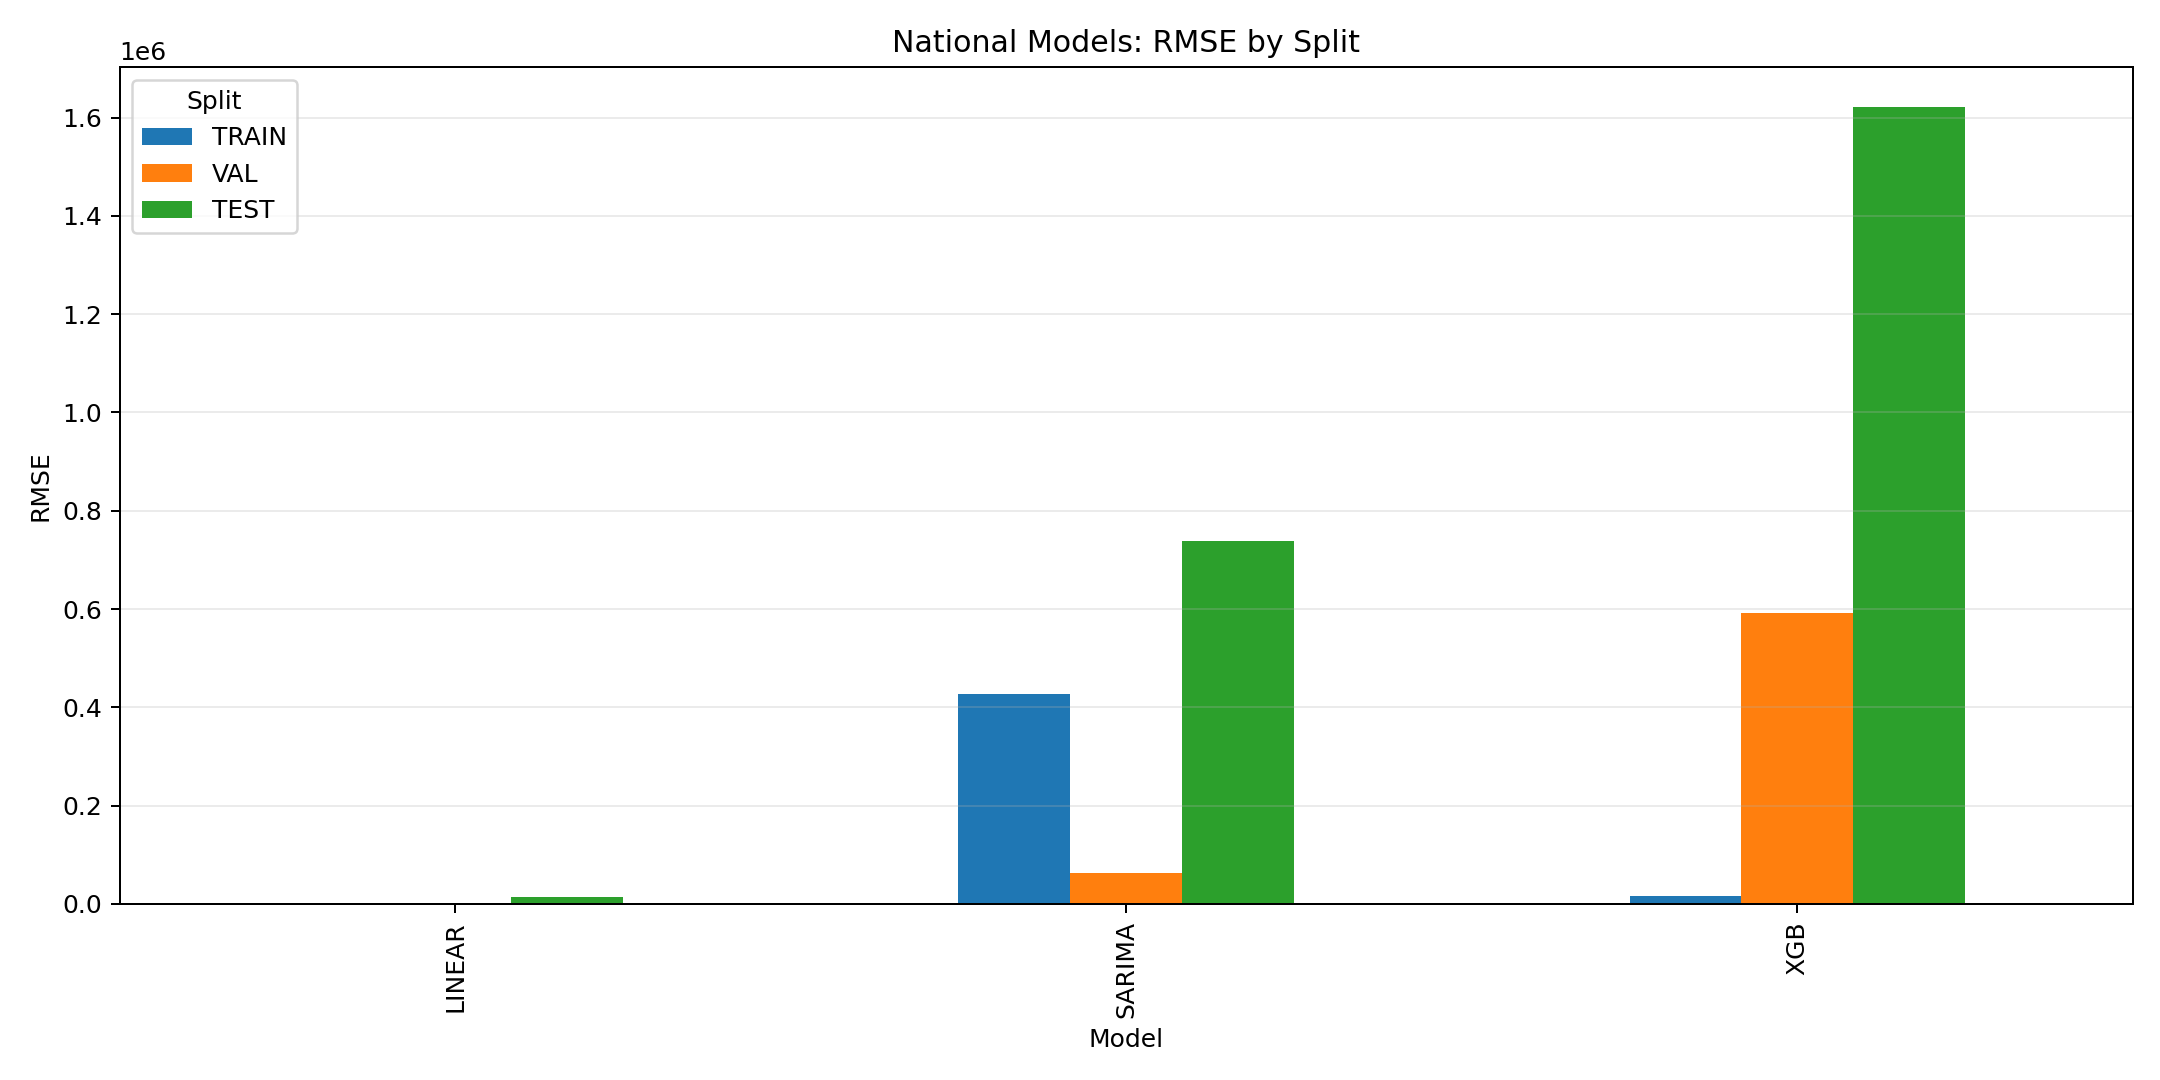


 models/overfitting_report/district_avg_mape_train_val_test.png


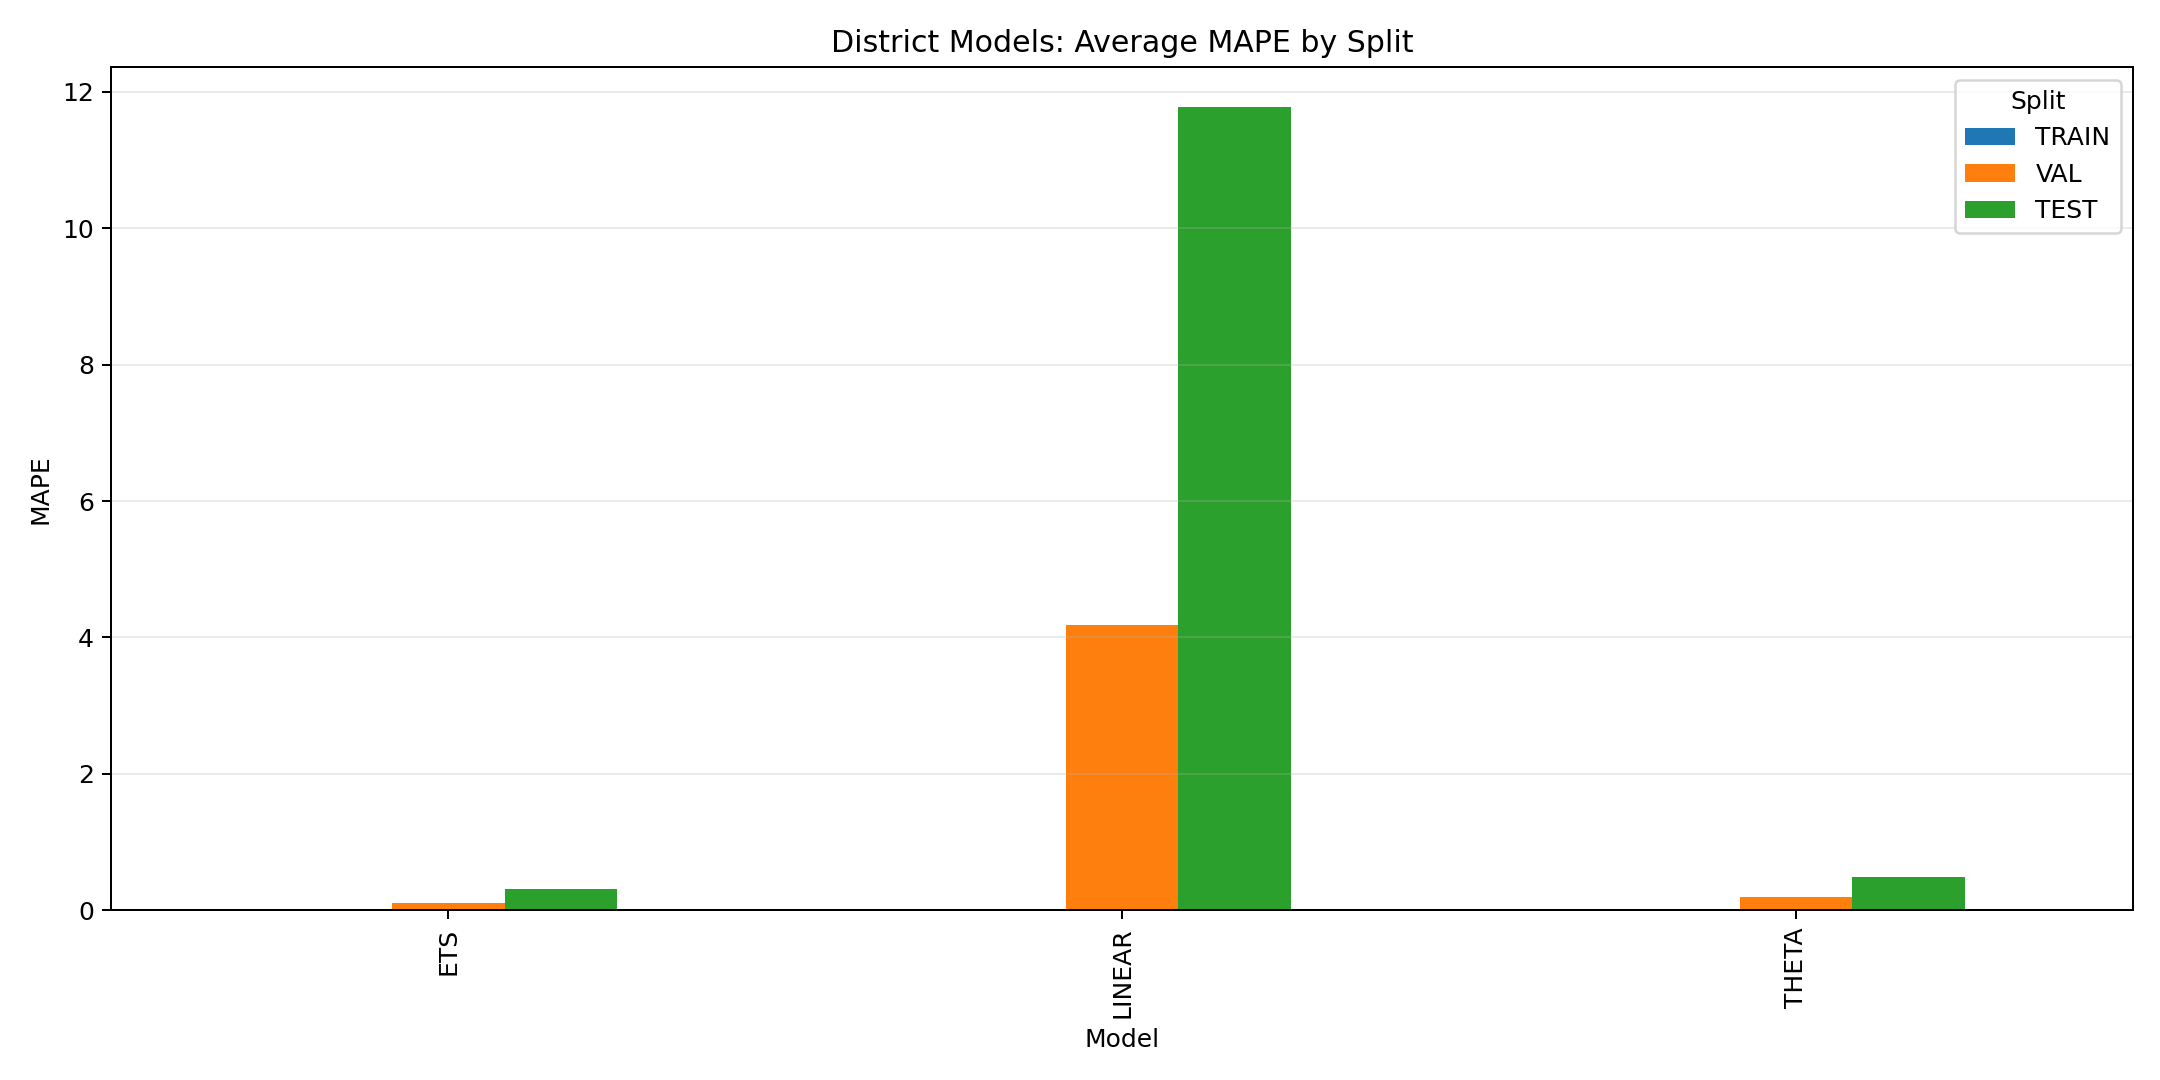


 models/overfitting_report/district_overfitting_gap.png


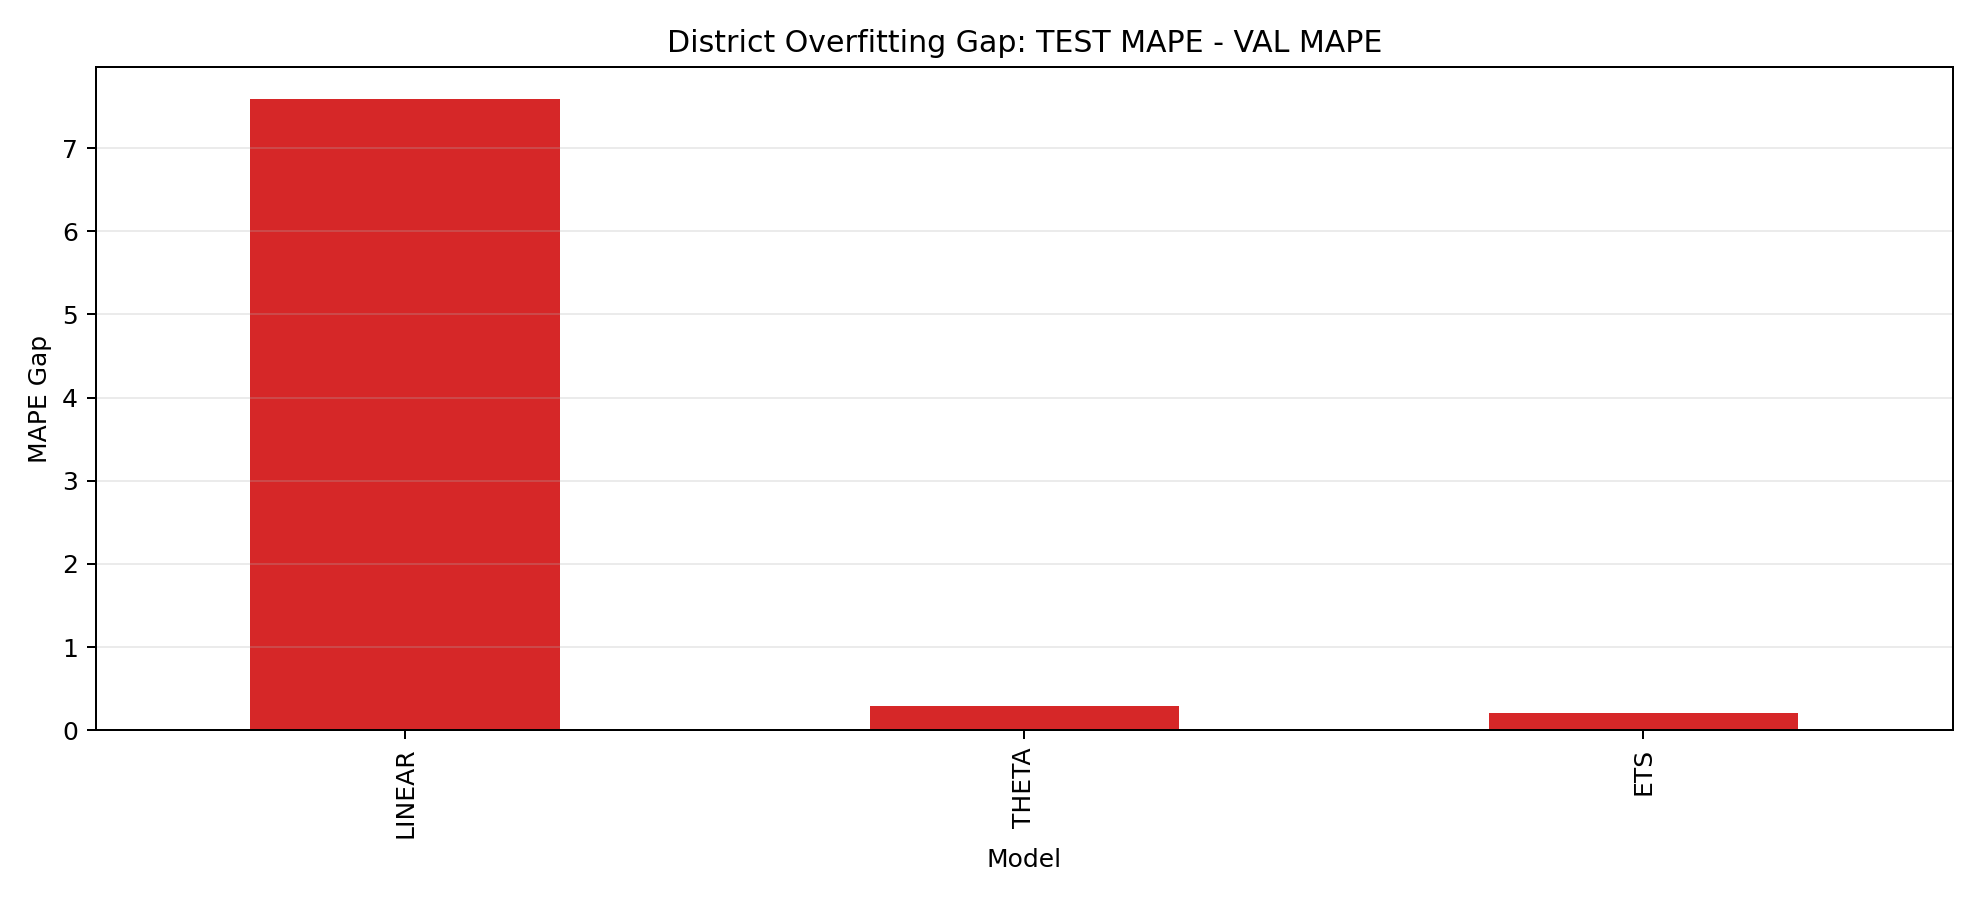

In [9]:
# Cell 9 - Show generated report images
from IPython.display import Image, display

image_files = [
    "models/overfitting_report/national_mape_train_val_test.png",
    "models/overfitting_report/national_rmse_train_val_test.png",
    "models/overfitting_report/district_avg_mape_train_val_test.png",
    "models/overfitting_report/district_overfitting_gap.png",
]

for f in image_files:
    p = PROJECT_ROOT / f
    print("\n", f)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print("Missing:", p)

In [11]:
# Cell 10 - Run prediction example (national)
import subprocess

cmd = [sys.executable, "src/predict.py", "--date", "2030-01-01"]
print("\n>>>", " ".join(cmd))
subprocess.run(cmd, check=True)


>>> c:\Users\HP\AppData\Local\Programs\Python\Python311\python.exe src/predict.py --date 2030-01-01


CompletedProcess(args=['c:\\Users\\HP\\AppData\\Local\\Programs\\Python\\Python311\\python.exe', 'src/predict.py', '--date', '2030-01-01'], returncode=0)

In [ ]:
# Cell 11 - Package report bundle for sharing
import shutil
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
bundle_dir = PROJECT_ROOT / f"report_bundle_{timestamp}"
bundle_dir.mkdir(exist_ok=True)

to_copy = [
    "models/national_best_model_leaderboard.csv",
    "models/national_train_val_test_metrics.csv",
    "models/national_split_info.csv",
    "models/national_predictions_by_split.csv",
    "models/district_best_model_leaderboard.csv",
    "models/national_tuning_candidates.csv",
    "models/district_tuning_candidates.csv",
    "models/national_driver_correlations.csv",
    "models/overfitting_report",
]

for item in to_copy:
    src = PROJECT_ROOT / item
    if not src.exists():
        continue
    dst = bundle_dir / src.name
    if src.is_dir():
        shutil.copytree(src, dst, dirs_exist_ok=True)
    else:
        shutil.copy2(src, dst)

zip_base = PROJECT_ROOT / f"population_report_{timestamp}"
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=bundle_dir)
print("Shareable zip created:", zip_path)

Shareable zip created: c:\Users\HP\Desktop\Population\population_report_20260427_210407.zip


## Cell 12 - Share checklist

For friends/supervisors, share:
1. This notebook (`Population_Hybrid_Colab_Workflow.ipynb`)
2. Your GitHub repo link
3. The generated zip from Cell 11
4. Optional: screenshots of Cell 8/9 plots for presentation slides